### Simple Linear Regression

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('data.csv')
df.sample(5)

,Weight,Height
5,78,162
12,78,177
8,95,182
10,100,183
2,48,123


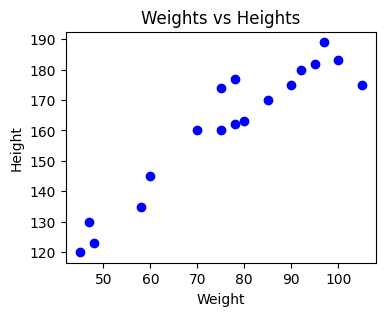

In [5]:
plt.figure(figsize=(4,3))
plt.scatter(df['Weight'],df['Height'], color='blue')
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Weights vs Heights')
plt.show()

In [10]:
X = df[['Weight']]
y = df['Height']

print(type(X))
print(type(y))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print(regression.coef_)
print(regression.intercept_)

[17.34878444]
164.57142857142858


In [19]:
y_pred = regression.predict(X_test)

In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error,r2_score
rmse = root_mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(rmse)
print(mae)
print(r2)
print(rmse/mae)

7.121388316302994
5.706333648776528
0.9115225444525974
1.2479796581522817


In [21]:
# is the model underfitting or overfitting?
y_pred_train = regression.predict(X_train)

r2_score_train = r2_score(y_train, y_pred_train)
r2_score_test = r2_score(y_test, y_pred)

print("train:", r2_score_train)
print("test:", r2_score_test)

# train ~ test => good model
# train >> test => overfitting  
# train << test => underfitting

train: 0.8401524300865686
test: 0.9115225444525974
